# Full Strategy: AI + Graph + Markowitz

Notebook ini menjalankan strategi lengkap yang menggabungkan:
1. **AI Gatekeeper (Random Forest)**: Untuk deteksi regime pasar (Bullish/Bearish)
2. **Graph Theory (MIS)**: Filter aset berdasarkan korelasi untuk mengurangi redundansi
3. **Markowitz Optimization**: Optimasi portfolio pada aset yang sudah difilter

**Benchmark**: Buy and hold Bitcoin (BTC)

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load Data
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(data)} rows of data.")
else:
    print("File data tidak ditemukan! Pastikan dataset ada di folder yang sama.")

Loaded 990 rows of data.


## 1. Feature Engineering & AI Training
Melatih AI Gatekeeper menggunakan data 2023-2024 untuk prediksi regime pasar.

In [2]:
# Returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

# Split
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

# Train RF
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)
test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"AI Model Accuracy: {accuracy_score(y_test, rf_model.predict(X_test)):.2%}")

AI Model Accuracy: 52.05%


## 2. Helper Functions
Fungsi untuk Graph Theory (MIS) dan Markowitz Optimization.

In [3]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    """Filter aset menggunakan Maximum Independent Set (MIS) berdasarkan korelasi."""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_assets_returns):
    """Optimasi Markowitz untuk maksimalisasi Sharpe Ratio."""
    if len(selected_assets_returns.columns) == 0: return {}
    if len(selected_assets_returns.columns) == 1: return {selected_assets_returns.columns[0]: 1.0}
        
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    initial_guess = len(mu) * [1. / len(mu)]
    
    try:
        result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_assets_returns.columns, result.x))
    except:
        return dict(zip(selected_assets_returns.columns, initial_guess))

## 3. Full Strategy Backtest
Menjalankan strategi lengkap: AI → Graph → Markowitz

In [4]:
def run_full_strategy(test_dates, returns, probs, lookback=30, corr_threshold=0.5):
    """Menjalankan strategi Full (AI + Graph + Markowitz)."""
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    
    for i, date in enumerate(test_dates[:-1]):
        # AI Gatekeeper: Cek regime pasar
        is_bull = probs.loc[date] > 0.5
        
        loc_idx = returns.index.get_loc(date)
        if loc_idx < lookback:
            weights = {t: 1.0/len(returns.columns) for t in returns.columns}
        else:
            window_returns = returns.iloc[loc_idx-lookback:loc_idx]
            
            if not is_bull:
                # Bearish: Pindah ke Cash
                weights = {'CASH': 1.0}
            else:
                # Bullish: Graph Filter + Markowitz
                selected_assets = get_mis_assets(window_returns, corr_threshold)
                weights = optimize_markowitz(window_returns[selected_assets])
        
        # Calculate daily return
        next_date = test_dates[i+1]
        next_day_rets = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' in weights:
            daily_ret = 0
        else:
            for asset, w in weights.items():
                daily_ret += w * next_day_rets[asset]
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(next_date)
        
    return pd.Series(history, index=dates)

# Run strategy
test_dates = X_test.index
print("Running Full Strategy (AI + Graph + Markowitz)...")
res_full = run_full_strategy(test_dates, returns, test_probs)

# Benchmark BTC
btc_series = data.loc[test_dates, 'BTC-USD']
btc_norm = btc_series / btc_series.iloc[0] * 10000

print("Backtest completed!")

Running Full Strategy (AI + Graph + Markowitz)...
Backtest completed!


## 4. Performance Metrics
Menghitung metrik performa strategi.

In [5]:
def calculate_metrics(series):
    """Hitung metrik performa portfolio."""
    returns = series.pct_change().dropna()
    total_return = (series.iloc[-1] / series.iloc[0] - 1) * 100
    annual_return = ((series.iloc[-1] / series.iloc[0]) ** (252 / len(series)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (annual_return / volatility) if volatility > 0 else 0
    max_dd = ((series / series.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Annual Return (%)': annual_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd,
        'Final Value': series.iloc[-1]
    }

# Calculate metrics
metrics_full = calculate_metrics(res_full)
metrics_btc = calculate_metrics(btc_norm)

# Create comparison table
metrics_df = pd.DataFrame({
    'Full Strategy': metrics_full,
    'BTC Benchmark': metrics_btc
})

print("\n=== Performance Metrics ===")
print(metrics_df.round(2))


=== Performance Metrics ===
                   Full Strategy  BTC Benchmark
Total Return (%)           77.62          -7.32
Annual Return (%)          48.68          -5.11
Volatility (%)             49.19          34.87
Sharpe Ratio                0.99          -0.15
Max Drawdown (%)          -31.50         -32.15
Final Value             17762.30        9268.06


## 5. Visualization
Visualisasi performa strategi vs benchmark.

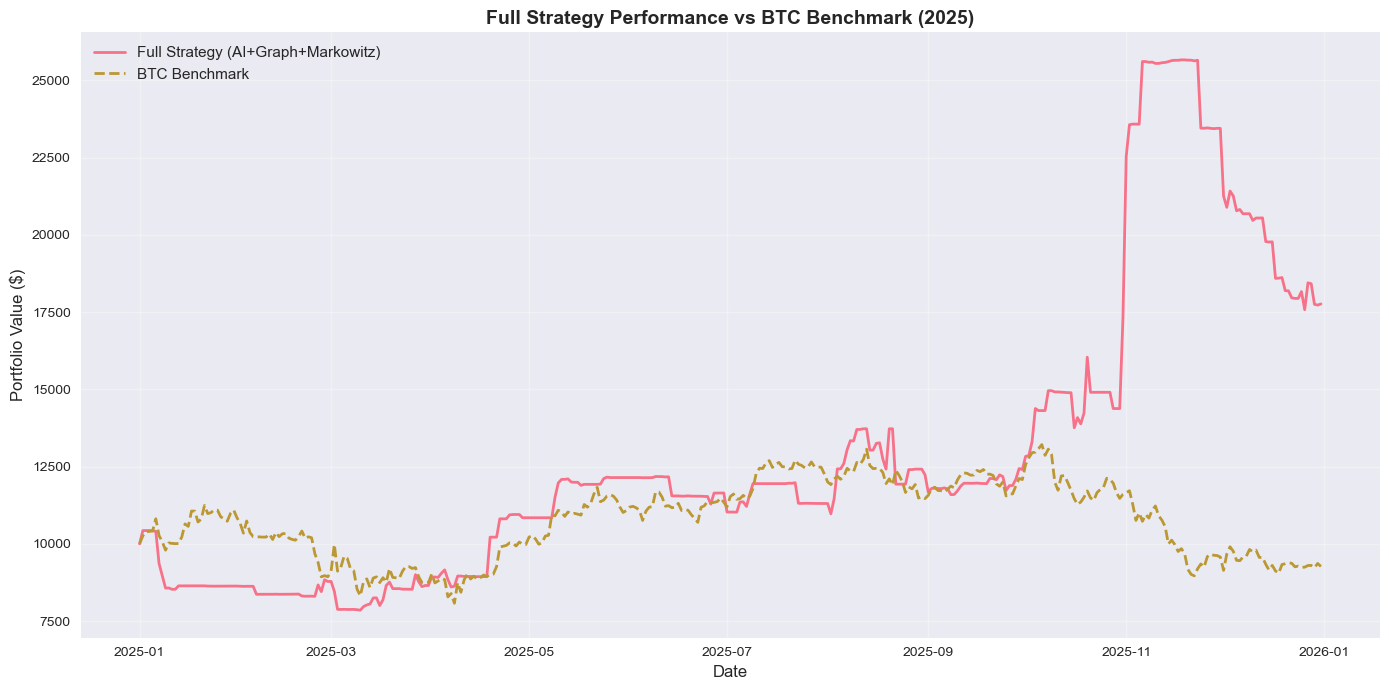

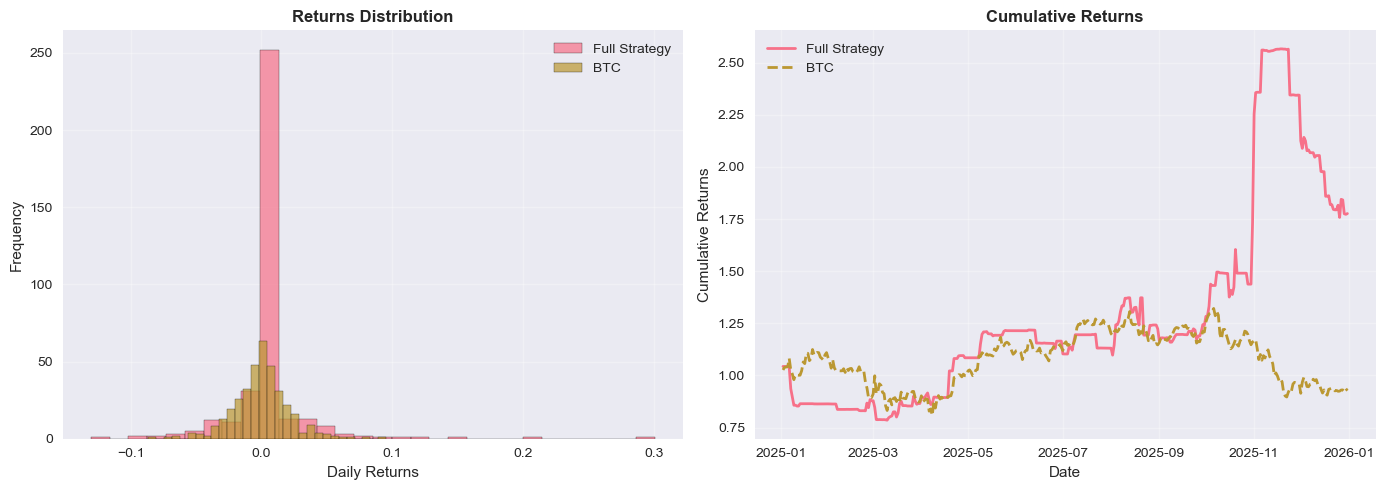

In [6]:
# Plot portfolio value over time
plt.figure(figsize=(14, 7))
plt.plot(res_full.index, res_full.values, label='Full Strategy (AI+Graph+Markowitz)', linewidth=2)
plt.plot(btc_norm.index, btc_norm.values, label='BTC Benchmark', linewidth=2, linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.title('Full Strategy Performance vs BTC Benchmark (2025)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily returns
returns_full = res_full.pct_change().dropna()
returns_btc = btc_norm.pct_change().dropna()

axes[0].hist(returns_full, bins=30, alpha=0.7, label='Full Strategy', edgecolor='black')
axes[0].hist(returns_btc, bins=30, alpha=0.7, label='BTC', edgecolor='black')
axes[0].set_xlabel('Daily Returns', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Returns Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative returns
cum_returns_full = (1 + returns_full).cumprod()
cum_returns_btc = (1 + returns_btc).cumprod()

axes[1].plot(cum_returns_full.index, cum_returns_full.values, label='Full Strategy', linewidth=2)
axes[1].plot(cum_returns_btc.index, cum_returns_btc.values, label='BTC', linewidth=2, linestyle='--')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Cumulative Returns', fontsize=11)
axes[1].set_title('Cumulative Returns', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary
Ringkasan hasil strategi Full (AI + Graph + Markowitz).

In [7]:
print("\n" + "="*60)
print("SUMMARY: Full Strategy (AI + Graph + Markowitz)")
print("="*60)
print(f"\nInitial Investment: $10,000")
print(f"Final Value: ${metrics_full['Final Value']:,.2f}")
print(f"Total Return: {metrics_full['Total Return (%)']:.2f}%")
print(f"Sharpe Ratio: {metrics_full['Sharpe Ratio']:.2f}")
print(f"Max Drawdown: {metrics_full['Max Drawdown (%)']:.2f}%")
print(f"\nBTC Benchmark:")
print(f"Final Value: ${metrics_btc['Final Value']:,.2f}")
print(f"Total Return: {metrics_btc['Total Return (%)']:.2f}%")
print(f"\nOutperformance: {metrics_full['Total Return (%)'] - metrics_btc['Total Return (%)']:.2f}%")
print("="*60)


SUMMARY: Full Strategy (AI + Graph + Markowitz)

Initial Investment: $10,000
Final Value: $17,762.30
Total Return: 77.62%
Sharpe Ratio: 0.99
Max Drawdown: -31.50%

BTC Benchmark:
Final Value: $9,268.06
Total Return: -7.32%

Outperformance: 84.94%
